# Instacart — exploratory data analysis

EDA only: what the data looks like and which facts shaped the design of the two-stage recommender.
Run `make data` first (reads `data/processed/*.parquet`, full dataset).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recsys.config import load_config

cfg = load_config()
d = cfg.paths.processed_dir
orders = pd.read_parquet(d / "orders.parquet")
prior = pd.read_parquet(d / "prior.parquet")
targets = pd.read_parquet(d / "targets.parquet")
products = pd.read_parquet(d / "products.parquet")
pd.Series({
    "users": orders.user_id.nunique(),
    "orders": len(orders),
    "prior order lines": len(prior),
    "products in catalogue": len(products),
    "products ever bought (prior)": prior.product_id.nunique(),
    "eval users (have a 'train' order)": targets.user_id.nunique(),
}).to_frame("count")

,count
users,206209
orders,3421083
prior order lines,32434489
products in catalogue,49688
products ever bought (prior),49677
eval users (have a 'train' order),131209


## Orders per user and basket size

,count,mean,std,min,25%,50%,75%,max
orders per user,206209.0,16.6,16.7,4.0,6.0,10.0,20.0,100.0


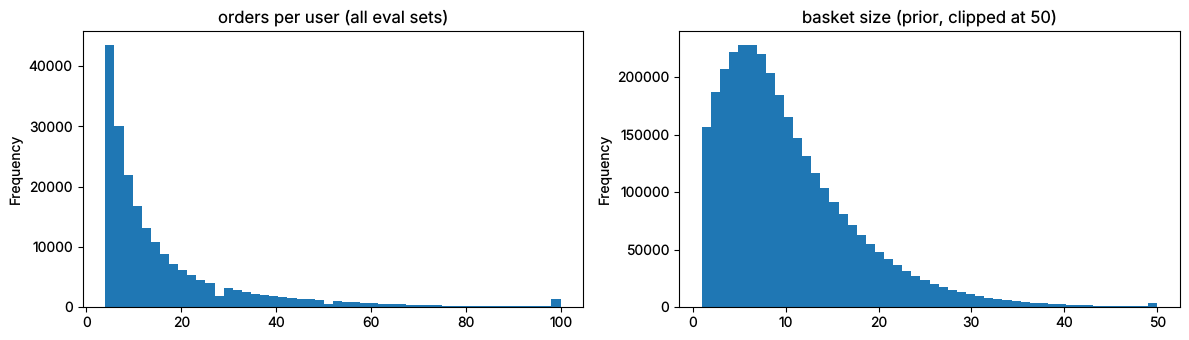

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
orders.groupby("user_id").size().plot.hist(bins=50, ax=ax[0], title="orders per user (all eval sets)")
prior.groupby("order_id").size().clip(upper=50).plot.hist(bins=50, ax=ax[1], title="basket size (prior, clipped at 50)")
plt.tight_layout()
orders.groupby("user_id").size().describe().round(1).to_frame("orders per user").T

## How repetitive is grocery shopping?

This is the key fact behind the design: a large part of the next basket is items the user bought before,
so the user's own history is a very strong candidate source (and a strong baseline). The rest are
first-time purchases, which bounds the recall any history-based system can reach.

In [3]:
hist_pairs = prior[["user_id", "product_id"]].drop_duplicates()
t = targets.merge(hist_pairs.assign(seen=1), on=["user_id", "product_id"], how="left")
print(f"prior lines that are reorders:            {prior.reordered.mean():.3f}")
print(f"target items bought before by the user:  {t.seen.notna().mean():.3f}")
print(f"target items that are first purchases:   {t.seen.isna().mean():.3f}")
print(f"avg target basket size:                  {targets.groupby('user_id').size().mean():.2f}")
print(f"avg distinct items in user history:      {hist_pairs.groupby('user_id').size().mean():.1f}")

prior lines that are reorders:            0.590
target items bought before by the user:  0.599
target items that are first purchases:   0.401
avg target basket size:                  10.55


avg distinct items in user history:      64.5


## Recency matters: reorder probability vs. how many orders ago the item was last bought

[Text(0.5, 0, 'orders since last purchase (clipped at 20)'),
 Text(0, 0.5, 'P(in next basket)')]

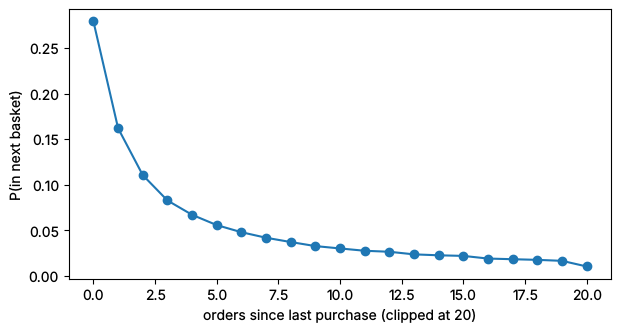

In [4]:
last = prior.groupby(["user_id", "product_id"]).order_number.max().rename("last_on").reset_index()
max_on = prior.groupby("user_id").order_number.max().rename("max_on")
last = last.join(max_on, on="user_id")
last["orders_since_last"] = (last.max_on - last.last_on).clip(upper=20)
last = last.merge(targets[["user_id", "product_id"]].assign(y=1), how="left").fillna({"y": 0})
last = last[last.user_id.isin(targets.user_id)]
ax = last.groupby("orders_since_last").y.mean().plot(marker="o", figsize=(7, 3.5))
ax.set(xlabel="orders since last purchase (clipped at 20)", ylabel="P(in next basket)")

## When do people order? (context features)

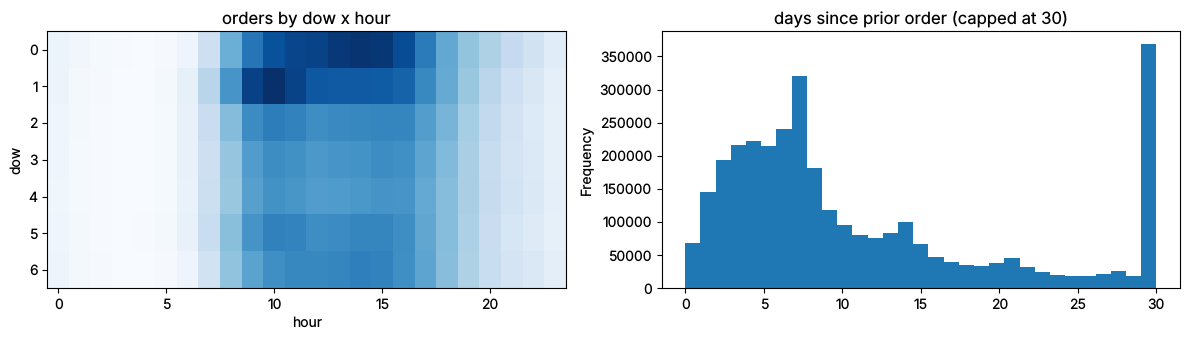

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
pivot = orders.pivot_table(index="order_dow", columns="order_hour_of_day", values="order_id", aggfunc="count")
ax[0].imshow(pivot, aspect="auto", cmap="Blues"); ax[0].set(title="orders by dow x hour", xlabel="hour", ylabel="dow")
orders.days_since_prior_order.plot.hist(bins=31, ax=ax[1], title="days since prior order (capped at 30)")
plt.tight_layout()

## Popularity is long-tailed

In [6]:
counts = prior.product_id.value_counts()
share = counts.cumsum() / counts.sum()
for q in (0.01, 0.05, 0.20):
    n = int(len(counts) * q)
    print(f"top {q:>4.0%} of products ({n:>5}) -> {share.iloc[n-1]:.1%} of order lines")
top = counts.head(10).rename_axis("product_id").reset_index(name="lines")
top.merge(products[["product_id", "product_name", "aisle"]], on="product_id")

top   1% of products (  496) -> 42.8% of order lines
top   5% of products ( 2483) -> 69.8% of order lines
top  20% of products ( 9935) -> 91.0% of order lines


,product_id,lines,product_name,aisle
0,24852,472565,Banana,fresh fruits
1,13176,379450,Bag of Organic Bananas,fresh fruits
2,21137,264683,Organic Strawberries,fresh fruits
3,21903,241921,Organic Baby Spinach,packaged vegetables fruits
4,47209,213584,Organic Hass Avocado,fresh fruits
5,47766,176815,Organic Avocado,fresh fruits
6,47626,152657,Large Lemon,fresh fruits
7,16797,142951,Strawberries,fresh fruits
8,26209,140627,Limes,fresh fruits
9,27845,137905,Organic Whole Milk,milk


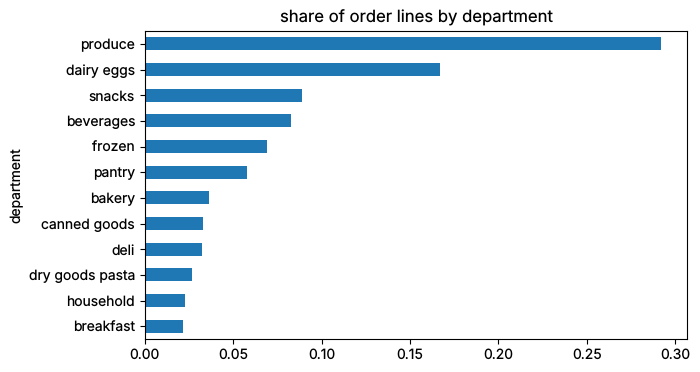

In [7]:
dep = prior.merge(products[["product_id", "department"]], on="product_id").department.value_counts(normalize=True)
dep.head(12).iloc[::-1].plot.barh(figsize=(7, 4), title="share of order lines by department");

## Item2Vec sanity check (after `make features`)

Nearest neighbours in the embedding space should be substitutes/complements from the same shopping mission.

In [8]:
from recsys.candidates.item2vec import ItemIndex
idx = ItemIndex.load(cfg.paths.models_dir)
name = products.set_index("product_id").product_name
def neighbours(pid, k=6):
    row = idx.rows(np.array([pid]))[0]
    sims, rows = idx.index.search(idx.vectors[row:row + 1], k + 1)
    return [f"{name[p]} ({s:.2f})" for p, s in zip(idx.product_ids[rows[0][1:]], sims[0][1:])]
for pid in (24852, 21903, 27845, 49683):   # banana, spinach, whole milk, cucumber
    print(f"{name[pid]:<28} -> {neighbours(pid)}")

Banana                       -> ['Organic Fuji Apple (0.82)', 'Total 0% Greek Yogurt (0.74)', 'Unsweetened Original Almond Breeze Almond Milk (0.74)', 'Almond Breeze Original Almond Milk (0.72)', 'Vanilla Almond Breeze Almond Milk (0.71)', 'Honeycrisp Apple (0.71)']
Organic Baby Spinach         -> ['Organic Unsweetened Almond Milk (0.93)', 'Organic Frozen Peas (0.90)', 'Organic Egg Whites (0.89)', 'Organic Unsweetened Vanilla Almond Milk (0.89)', 'Organic Spring Mix (0.88)', 'Organic Baby Carrots (0.88)']
Organic Whole Milk           -> ['Whole Milk Plain Yogurt (0.87)', 'Organic Whole String Cheese (0.86)', 'Organic Reduced Fat Milk (0.85)', 'Organic Lowfat 1% Milk (0.84)', 'Organic Mini Homestyle Waffles (0.84)', 'Organic Homestyle Waffles (0.83)']
Cucumber Kirby               -> ['Roma Tomato (0.79)', 'Yellow Bell Pepper (0.78)', 'Russet Potato (0.75)', 'Red Onion (0.75)', 'Organic Avocado (0.74)', 'Orange Bell Pepper (0.73)']


## Takeaways for the design

* ~60% of next-basket items were bought before → history candidates + recency/frequency features dominate.
* ~40% are first-time purchases → the candidate generator caps achievable recall; Item2Vec/aisle/global sources add a little.
* Strong recency effect → `orders_since_last`, `days_since_last`, streak features.
* Time-of-day and order-gap patterns → context features (hour, dow, days since prior order).
* Long-tailed popularity → global popularity is a weak baseline but a sensible cold-start fallback.